# QR / FTQR / SAQR Model Validation

This notebook validates the level-1 Queue-Reactive model variants on the reconstructed event-flow dataset.

Scope:
- FTQR decomposition: partial vs full-consumption cancel and market events
- SAQR diagnostics: AES-normalized size-aware intensities, support, row-normalized heatmaps, and diagonal-mass checks

Constraints respected:
- no LOB reconstruction changes
- no timestamp-correction changes
- no QR event-flow pipeline changes


In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import models.common as common_module
import models.qr as qr_module
import models.qru as qru_module
import models.ftqr as ftqr_module
import models.saqr as saqr_module

importlib.reload(common_module)
importlib.reload(qr_module)
importlib.reload(qru_module)
importlib.reload(ftqr_module)
importlib.reload(saqr_module)

from models.common import calibrate_common
from models.qr import calibrate_qr
from models.qru import calibrate_qru
from models.ftqr import calibrate_ftqr
from models.saqr import calibrate_saqr


In [2]:
EVENT_FLOW_PATH = ROOT / "data/processed/FGBL_event_flow.parquet"
RAW_DIR = ROOT / "data/raw"
FTQR_DIR = ROOT / "data/processed/ftqr_diagnostics"
LEVEL = 1
MIN_OBS = 50
AES_CROP_MAX = 30

common = calibrate_common(
    event_flow_path=str(EVENT_FLOW_PATH),
    raw_dir=str(RAW_DIR),
    level=LEVEL,
    min_obs=MIN_OBS,
)
qr_cal = calibrate_qr(str(EVENT_FLOW_PATH), raw_dir=str(RAW_DIR), level=LEVEL, min_obs=MIN_OBS, common=common)
qru_cal = calibrate_qru(str(EVENT_FLOW_PATH), raw_dir=str(RAW_DIR), level=LEVEL, min_obs=MIN_OBS, common=common)
ftqr_cal = calibrate_ftqr(str(EVENT_FLOW_PATH), raw_dir=str(RAW_DIR), level=LEVEL, min_obs=MIN_OBS, common=common)
saqr_cal = calibrate_saqr(str(EVENT_FLOW_PATH), raw_dir=str(RAW_DIR), level=LEVEL, min_obs=MIN_OBS, smoothing_alpha=25.0, common=common)

summary_df = pd.DataFrame(
    {
        "level": [common.level],
        "aes_level": [common.aes_level],
        "n_bins": [len(common.intensity_df)],
        "ftqr_bins": [len(ftqr_cal.intensity_df)],
        "saqr_joint_rows": [len(saqr_cal.joint_size_df)],
        "qru_unit_size": [qru_cal.unit_size],
    }
)
display(summary_df)


,level,aes_level,n_bins,ftqr_bins,saqr_joint_rows,qru_unit_size
0,1,13.27615,301,301,92898,14


## FTQR Decomposition

The FTQR section uses the saved monthly diagnostics and checks the core identities:

- `lambda_M^QR(n) = lambda_M^FTQR(n) + lambda_M_all^FTQR(n)`
- `lambda_C^QR(n) = lambda_C^FTQR(n) + lambda_C_all^FTQR(n)`


In [3]:
ftqr_small = pd.read_csv(FTQR_DIR / "ftqr_small_n_table.csv")
ftqr_full_probs = pd.read_csv(FTQR_DIR / "ftqr_full_consumption_probabilities.csv")
ftqr_cond_sizes = pd.read_csv(FTQR_DIR / "ftqr_conditional_size_distributions.csv")
ftqr_sim = pd.read_csv(FTQR_DIR / "qr_qru_ftqr_simulation_summary.csv")

ftqr_identity_m = (ftqr_small["lambda_M_qr"] - (ftqr_small["lambda_M_ftqr"] + ftqr_small["lambda_M_all_ftqr"])).abs().max()
ftqr_identity_c = (ftqr_small["lambda_C_qr"] - (ftqr_small["lambda_C_ftqr"] + ftqr_small["lambda_C_all_ftqr"])).abs().max()
display(pd.DataFrame({
    "metric": ["max |M identity error|", "max |C identity error|"],
    "value": [ftqr_identity_m, ftqr_identity_c],
} ))
display(ftqr_small.head(10))


,metric,value
0,max |M identity error|,7.105427e-15
1,max |C identity error|,3.552714e-15


,n,n_obs,sum_dt,ait,Lambda,count_L,lambda_L_qr,count_C,lambda_C_qr,count_M,...,lambda_C_all_ftqr,lambda_M_all_ftqr,lambda_global,lambda_M_total_ftqr,lambda_C_total_ftqr,lambda_L_qru,lambda_C_qru,lambda_M_qru,p_full_C,p_full_M
0,1,135758,3272.779263,0.024107,41.480952,94804,28.967429,35653,10.893799,122790,...,3.016091,14.423826,77.379799,37.518571,10.893799,28.967429,10.893799,37.518571,0.276863,0.384445
1,2,139099,3013.994294,0.021668,46.151050,82428,27.348426,41968,13.924379,77119,...,0.903784,1.946586,66.859782,25.586976,13.924379,27.348426,13.924379,25.586976,0.064907,0.076077
2,3,146725,2952.130687,0.020120,49.701390,81776,27.700671,47306,16.024358,66337,...,0.615488,0.998262,66.195918,22.470889,16.024358,27.700671,16.024358,22.470889,0.038410,0.044425
3,4,144821,2459.646924,0.016984,58.878776,76966,31.291483,50137,20.383820,56705,...,0.155713,0.422825,74.729425,23.054122,20.383820,31.291483,20.383820,23.054122,0.007639,0.018341
4,5,150923,2402.161810,0.015916,62.827991,79761,33.203842,54570,22.717038,51636,...,0.138625,0.281413,77.416517,21.495638,22.717038,33.203842,22.717038,21.495638,0.006102,0.013092
5,6,149371,2358.340282,0.015788,63.337340,78467,33.272128,56400,23.915124,46616,...,0.149258,0.221342,76.953696,19.766444,23.915124,33.272128,23.915124,19.766444,0.006241,0.011198
6,7,146108,2581.365150,0.017668,56.601059,77408,29.987234,56630,21.938004,42307,...,0.158831,0.154569,68.314628,16.389390,21.938004,29.987234,21.938004,16.389390,0.007240,0.009431
7,8,156760,3041.617667,0.019403,51.538364,86550,28.455253,60622,19.930842,41165,...,0.145646,0.080878,61.920011,13.533917,19.930842,28.455253,19.930842,13.533917,0.007308,0.005976
8,9,167797,3091.168141,0.018422,54.282715,89344,28.902989,66380,21.474083,40138,...,0.000971,0.022969,63.361807,12.984735,21.474083,28.902989,21.474083,12.984735,0.000045,0.001769
9,10,169772,3284.837322,0.019349,51.683534,90481,27.545047,68091,20.728880,38501,...,0.001218,0.012177,59.994752,11.720824,20.728880,27.545047,20.728880,11.720824,0.000059,0.001039


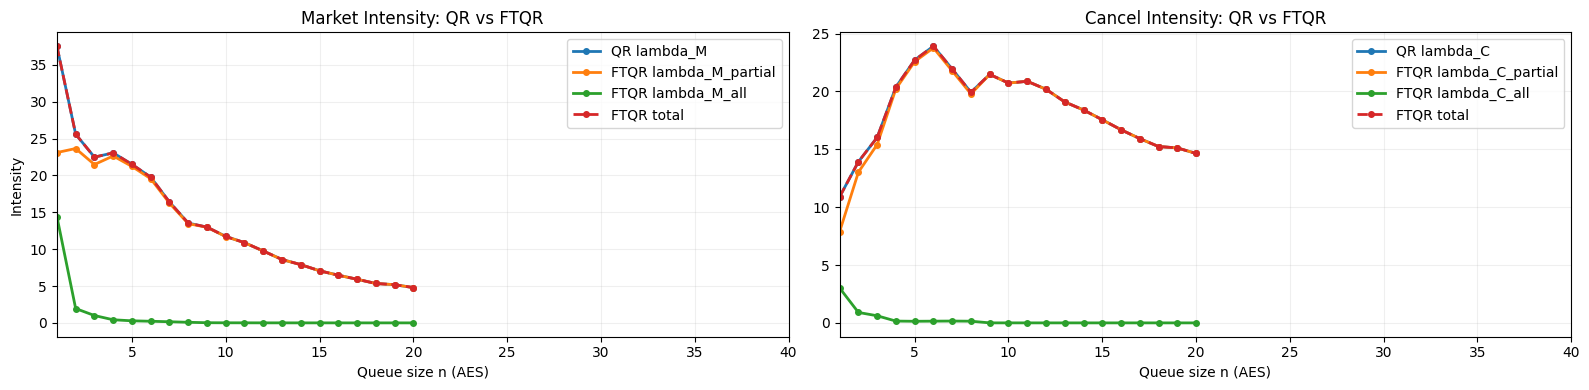

In [4]:
plot_df = ftqr_small[ftqr_small["n"] <= 40].copy()
marker_kws = dict(marker="o", markersize=4)

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)

axes[0].plot(plot_df["n"], plot_df["lambda_M_qr"], linewidth=2, label="QR lambda_M", **marker_kws)
axes[0].plot(plot_df["n"], plot_df["lambda_M_ftqr"], linewidth=2, label="FTQR lambda_M_partial", **marker_kws)
axes[0].plot(plot_df["n"], plot_df["lambda_M_all_ftqr"], linewidth=2, label="FTQR lambda_M_all", **marker_kws)
axes[0].plot(plot_df["n"], plot_df["lambda_M_ftqr"] + plot_df["lambda_M_all_ftqr"], linewidth=2, linestyle="--", label="FTQR total", **marker_kws)
axes[0].set_title("Market Intensity: QR vs FTQR")
axes[0].set_xlabel("Queue size n (AES)")
axes[0].set_ylabel("Intensity")
axes[0].set_xlim(1, 40)
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(plot_df["n"], plot_df["lambda_C_qr"], linewidth=2, label="QR lambda_C", **marker_kws)
axes[1].plot(plot_df["n"], plot_df["lambda_C_ftqr"], linewidth=2, label="FTQR lambda_C_partial", **marker_kws)
axes[1].plot(plot_df["n"], plot_df["lambda_C_all_ftqr"], linewidth=2, label="FTQR lambda_C_all", **marker_kws)
axes[1].plot(plot_df["n"], plot_df["lambda_C_ftqr"] + plot_df["lambda_C_all_ftqr"], linewidth=2, linestyle="--", label="FTQR total", **marker_kws)
axes[1].set_title("Cancel Intensity: QR vs FTQR")
axes[1].set_xlabel("Queue size n (AES)")
axes[1].set_xlim(1, 40)
axes[1].grid(alpha=0.2)
axes[1].legend()

fig.tight_layout()


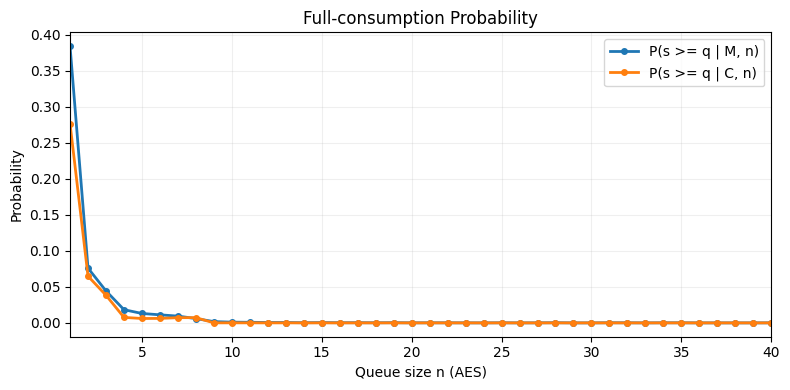

In [5]:
prob_plot = ftqr_full_probs[ftqr_full_probs["n"] <= 40].copy()
prob_m = prob_plot[prob_plot["eta"] == "M"].copy()
prob_c = prob_plot[prob_plot["eta"] == "C"].copy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(prob_m["n"], prob_m["p_full"], linewidth=2, marker="o", markersize=4, label="P(s >= q | M, n)")
ax.plot(prob_c["n"], prob_c["p_full"], linewidth=2, marker="o", markersize=4, label="P(s >= q | C, n)")
ax.set_title("Full-consumption Probability")
ax.set_xlabel("Queue size n (AES)")
ax.set_ylabel("Probability")
ax.set_xlim(1, 40)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()


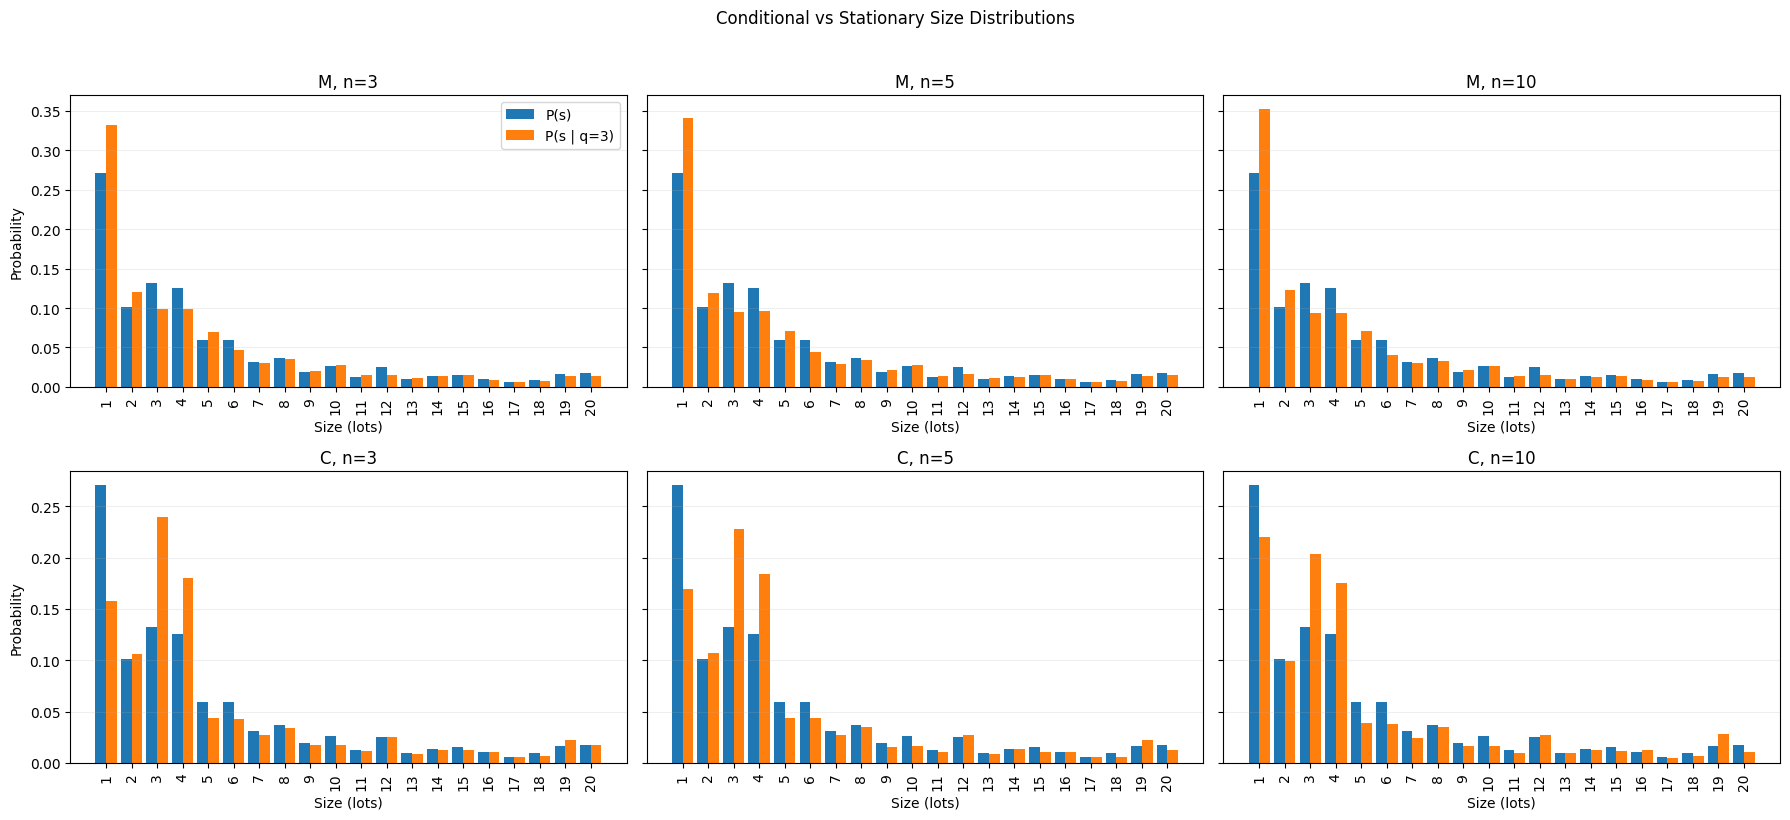

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey="row")
for row, eta in enumerate(["M", "C"]):
    eta_df = ftqr_cond_sizes[ftqr_cond_sizes["eta"] == eta].copy()
    for col, n in enumerate([3, 5, 10]):
        sub = eta_df[(eta_df["n"] == n) & (eta_df["size"] <= 20)].copy()
        if sub.empty:
            continue
        sub["prob_cond"] = sub["count"] / sub["count"].sum()
        sub["prob_uncond"] = sub["count_uncond"] / sub["count_uncond"].sum()
        sub = sub.sort_values("size")
        x = np.arange(len(sub))
        width = 0.42
        axes[row, col].bar(x - width / 2, sub["prob_uncond"], width=width, label="P(s)")
        axes[row, col].bar(x + width / 2, sub["prob_cond"], width=width, label=f"P(s | q={n})")
        axes[row, col].set_xticks(x)
        axes[row, col].set_xticklabels(sub["size"].astype(int), rotation=90)
        axes[row, col].set_title(f"{eta}, n={n}")
        axes[row, col].set_xlabel("Size (lots)")
        axes[row, col].grid(axis="y", alpha=0.2)
axes[0, 0].set_ylabel("Probability")
axes[1, 0].set_ylabel("Probability")
axes[0, 0].legend()
fig.suptitle("Conditional vs Stationary Size Distributions", y=1.02)
fig.tight_layout()


### QR vs QRU

QRU changes the simulation size rule to a constant `ceil(AES)` size, but it does not change the calibrated `lambda_L`, `lambda_C`, `lambda_M` curves. The overlay below is therefore expected to coincide.

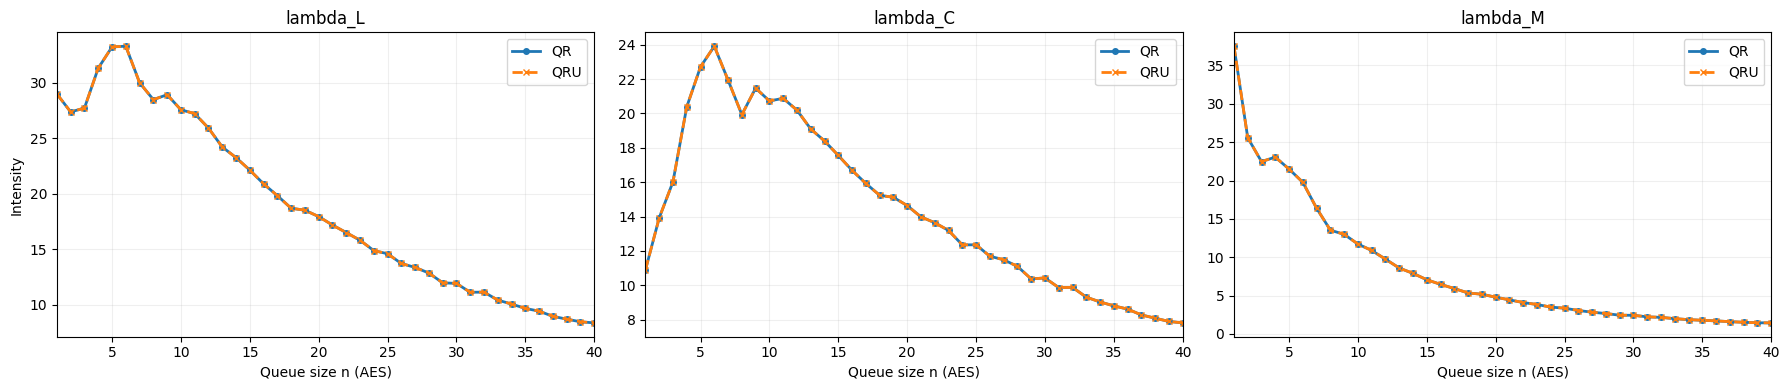

In [7]:
qr_plot = common.intensity_df[common.intensity_df["n"] <= 40].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for ax, col, title in zip(axes, ["lambda_L", "lambda_C", "lambda_M"], ["lambda_L", "lambda_C", "lambda_M"]):
    ax.plot(qr_plot["n"], qr_plot[col], linewidth=2, marker="o", markersize=4, label="QR")
    ax.plot(qr_plot["n"], qr_plot[col], linewidth=2, linestyle="--", marker="x", markersize=4, label="QRU")
    ax.set_title(title)
    ax.set_xlabel("Queue size n (AES)")
    ax.set_xlim(1, 40)
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_ylabel("Intensity")
fig.tight_layout()


In [8]:
peak_qr = int(ftqr_small.loc[ftqr_small["lambda_M_qr"].idxmax(), "n"])
peak_ftqr_total = int((ftqr_small["lambda_M_ftqr"] + ftqr_small["lambda_M_all_ftqr"]).idxmax())
display(ftqr_sim)

ftqr_conclusion = f"""
### FTQR conclusion

- FTQR is implemented correctly: the decomposition identities hold up to numerical precision (`M` error = `{ftqr_identity_m:.2e}`, `C` error = `{ftqr_identity_c:.2e}`).
- FTQR redistributes removal intensity between partial and full-consumption events.
- On this Bund dataset, full-consumption effects are concentrated mainly at the very smallest queues (`P(s>=q|M,n=1)={prob_m.loc[prob_m['n']==1, 'p_full'].iloc[0]:.3f}`, `P(s>=q|C,n=1)={prob_c.loc[prob_c['n']==1, 'p_full'].iloc[0]:.3f}`) and decay quickly with `n`.
- FTQR does **not** change the total `lambda_M(n)` shape when that hump is not already in the data; the QR and FTQR-total curves coincide by construction.
"""
display(Markdown(ftqr_conclusion))


,model,steps,mean_queue,depletion_rate,price_vol,mean_dt
0,QR,25000.0,746.28432,0.00156,0.039495,0.091684
1,QRU,25000.0,559.61164,0.00112,0.033467,0.067751
2,FTQR,25000.0,722.62376,0.00044,0.020976,0.093262



### FTQR conclusion

- FTQR is implemented correctly: the decomposition identities hold up to numerical precision (`M` error = `7.11e-15`, `C` error = `3.55e-15`).
- FTQR redistributes removal intensity between partial and full-consumption events.
- On this Bund dataset, full-consumption effects are concentrated mainly at the very smallest queues (`P(s>=q|M,n=1)=0.384`, `P(s>=q|C,n=1)=0.277`) and decay quickly with `n`.
- FTQR does **not** change the total `lambda_M(n)` shape when that hump is not already in the data; the QR and FTQR-total curves coincide by construction.


## SAQR Diagnostics

This section rebuilds the SAQR matrices with **both axes normalized in AES units**.

Implementation choice:
- queue size axis: `n = q_before_aes` from the validated QR pipeline
- size axis: `size_aes = ceil(size / AES_level)` so the event-size bins are on the same discrete AES scale as queue size

The SAQR estimator used is:

`lambda_(eta,s)(n) = Lambda(n) * count(eta, s, n) / count(n)`

Two heatmap types are shown below:
- **Support heatmaps**: observation counts in each `(n, size_aes)` bin. These diagnose whether dark regions are due to true sparsity.
- **Intensity heatmaps**: AES-normalized SAQR intensities aggregated on `(n, size_aes)`. These show where the estimated arrival/removal mass actually sits.

For cancel and market orders, the displayed heatmaps are restricted to the meaningful triangular domain `size_aes <= n`. Limit orders are shown on the full rectangle because add sizes are not constrained by current queue size in the same way.


In [9]:
paper_cmap = LinearSegmentedColormap.from_list(
    "paper_like",
    ["#000000", "#08306b", "#2171b5", "#6baed6", "#fff7bc"],
)

joint_df = saqr_cal.joint_size_df.copy()
joint_df["size_aes"] = np.ceil(joint_df["size"] / common.aes_level).astype(int)

saqr_aes = (
    joint_df.groupby(["eta", "n", "size_aes"], as_index=False)
    .agg(
        count=("count", "sum"),
        lambda_eta_size=("lambda_eta_size", "sum"),
        n_obs=("n_obs", "first"),
        Lambda=("Lambda", "first"),
    )
)
saqr_aes["row_prob"] = saqr_aes.groupby(["eta", "n"])["lambda_eta_size"].transform(lambda x: x / x.sum())

support_by_n = saqr_aes.groupby(["eta", "n"], as_index=False)["count"].sum()
support_by_s = saqr_aes.groupby(["eta", "size_aes"], as_index=False)["count"].sum()
support_small_n = support_by_n[support_by_n["n"] <= 20].copy()
support_small_s = support_by_s[support_by_s["size_aes"] <= 20].copy()

display(pd.DataFrame({
    "metric": ["queue n min", "queue n max", "size_aes min", "size_aes max", "rows"],
    "value": [saqr_aes["n"].min(), saqr_aes["n"].max(), saqr_aes["size_aes"].min(), saqr_aes["size_aes"].max(), len(saqr_aes)],
}))
display(support_small_n.head(20))
display(support_small_s.head(20))


,metric,value
0,queue n min,1
1,queue n max,526
2,size_aes min,1
3,size_aes max,264
4,rows,14273


,eta,n,count
0,C,1,35653
1,C,2,41968
2,C,3,47306
3,C,4,50137
4,C,5,54570
5,C,6,56400
6,C,7,56630
7,C,8,60622
8,C,9,66380
9,C,10,68091


,eta,size_aes,count
0,C,1,4621639
1,C,2,629750
2,C,3,635496
3,C,4,140688
4,C,5,106075
5,C,6,62590
6,C,7,60459
7,C,8,78364
8,C,9,16767
9,C,10,10077


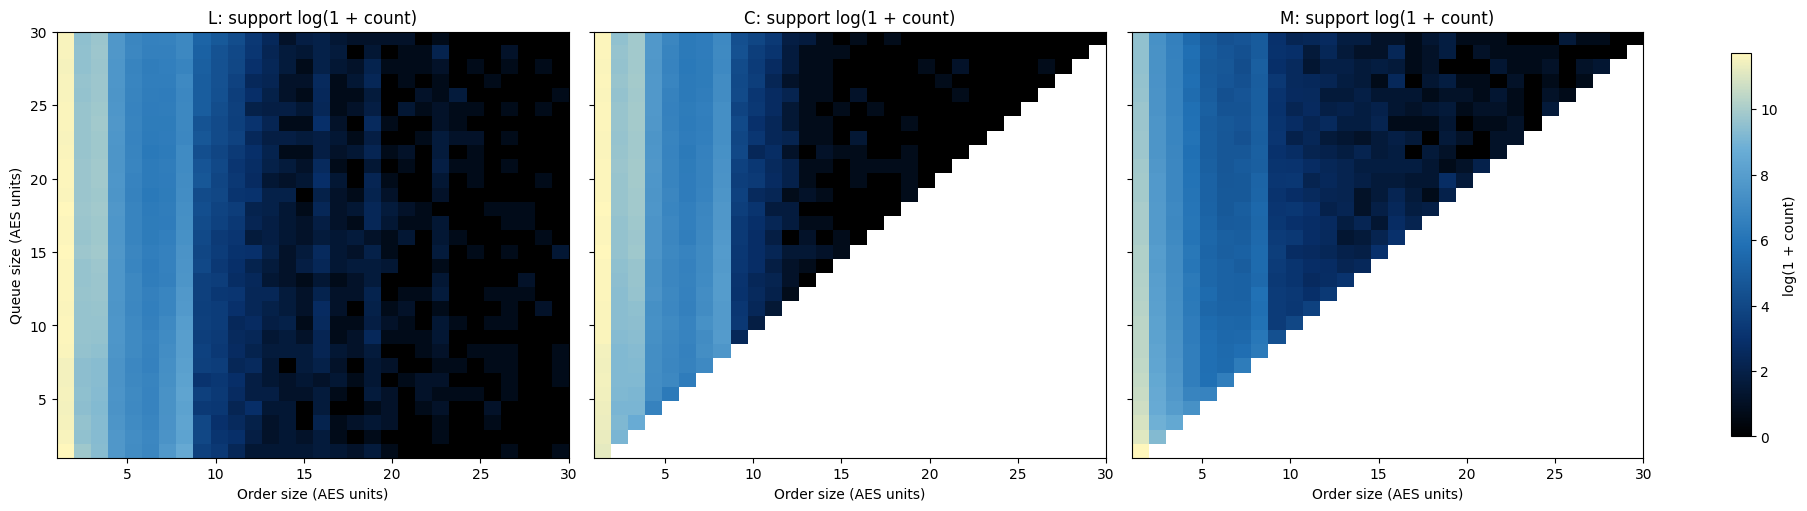

In [10]:
def build_heatmap(df, eta, value_col, n_max=AES_CROP_MAX, s_max=AES_CROP_MAX, triangular=False):
    sub = df[(df["eta"] == eta) & (df["n"] <= n_max) & (df["size_aes"] <= s_max)].copy()
    heat = sub.pivot_table(index="n", columns="size_aes", values=value_col, aggfunc="sum", fill_value=0.0)
    heat = heat.reindex(index=range(1, n_max + 1), columns=range(1, s_max + 1), fill_value=0.0)
    if triangular:
        row_vals = heat.index.to_numpy()[:, None]
        col_vals = heat.columns.to_numpy()[None, :]
        heat = heat.mask(col_vals > row_vals)
    return heat

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, eta in zip(axes, ["L", "C", "M"]):
    heat = build_heatmap(saqr_aes, eta, "count", triangular=(eta != "L"))
    im = ax.imshow(
        np.log1p(heat.to_numpy()),
        aspect="auto",
        origin="lower",
        cmap=paper_cmap,
        extent=[1, AES_CROP_MAX, 1, AES_CROP_MAX],
    )
    ax.set_title(f"{eta}: support log(1 + count)")
    ax.set_xlabel("Order size (AES units)")
    ax.grid(False)
axes[0].set_ylabel("Queue size (AES units)")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label="log(1 + count)")


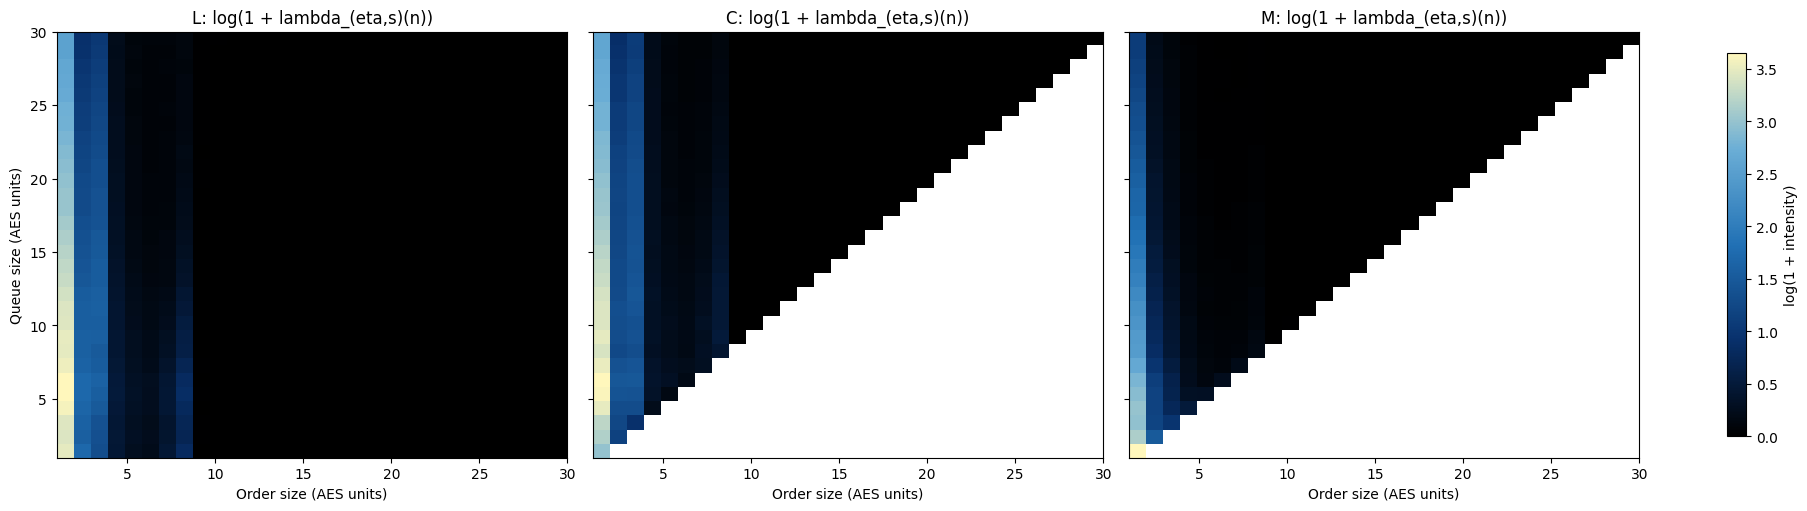

In [11]:
lambda_heatmaps = {eta: build_heatmap(saqr_aes, eta, "lambda_eta_size", triangular=(eta != "L")) for eta in ["L", "C", "M"]}
row_heatmaps = {eta: build_heatmap(saqr_aes, eta, "row_prob", triangular=(eta != "L")) for eta in ["L", "C", "M"]}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, eta in zip(axes, ["L", "C", "M"]):
    heat = lambda_heatmaps[eta]
    im = ax.imshow(
        np.log1p(heat.to_numpy()),
        aspect="auto",
        origin="lower",
        cmap=paper_cmap,
        extent=[1, AES_CROP_MAX, 1, AES_CROP_MAX],
    )
    ax.set_title(f"{eta}: log(1 + lambda_(eta,s)(n))")
    ax.set_xlabel("Order size (AES units)")
    ax.grid(False)
axes[0].set_ylabel("Queue size (AES units)")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label="log(1 + intensity)")


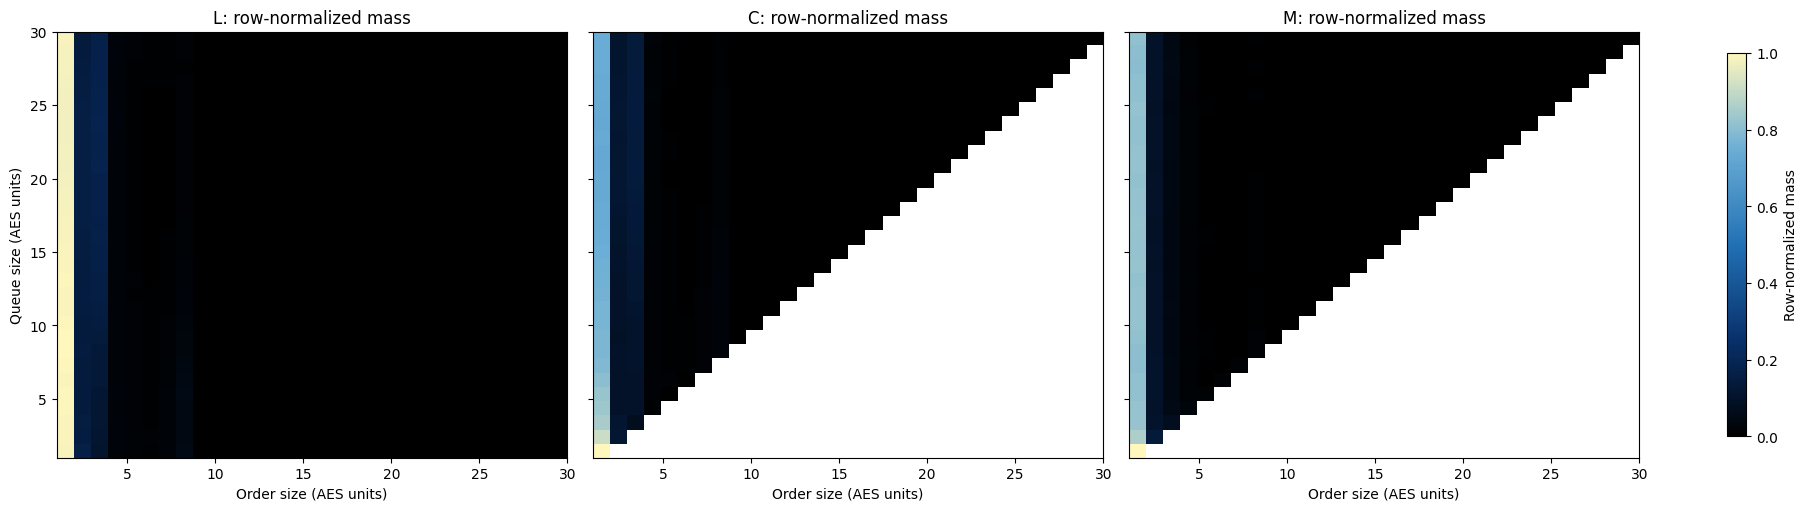

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, eta in zip(axes, ["L", "C", "M"]):
    heat = row_heatmaps[eta]
    vmax = np.nanmax(heat.to_numpy()) if np.isfinite(np.nanmax(heat.to_numpy())) else 1.0
    im = ax.imshow(
        heat.to_numpy(),
        aspect="auto",
        origin="lower",
        cmap=paper_cmap,
        vmin=0.0,
        vmax=max(0.05, float(vmax)),
        extent=[1, AES_CROP_MAX, 1, AES_CROP_MAX],
    )
    ax.set_title(f"{eta}: row-normalized mass")
    ax.set_xlabel("Order size (AES units)")
    ax.grid(False)
axes[0].set_ylabel("Queue size (AES units)")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label="Row-normalized mass")


In [13]:
diag_rows = []
for eta in ["C", "M"]:
    sub = saqr_aes[(saqr_aes["eta"] == eta) & (saqr_aes["n"] <= AES_CROP_MAX) & (saqr_aes["size_aes"] <= AES_CROP_MAX)].copy()
    total_rows = sub["n"].nunique()
    diag_mass = sub.loc[(sub["size_aes"] - sub["n"]).abs() <= 1, "row_prob"].sum() / total_rows
    above_mass = sub.loc[sub["size_aes"] > sub["n"] + 1, "row_prob"].sum() / total_rows
    below_mass = sub.loc[sub["size_aes"] < sub["n"] - 1, "row_prob"].sum() / total_rows
    diag_rows.append({
        "eta": eta,
        "diag_mass": diag_mass,
        "above_diag_mass": above_mass,
        "below_diag_mass": below_mass,
    })
diag_df = pd.DataFrame(diag_rows)
display(diag_df)


,eta,diag_mass,above_diag_mass,below_diag_mass
0,C,0.079690,0.001256,0.919054
1,M,0.079389,0.000000,0.920611


In [14]:
c_diag = diag_df.loc[diag_df["eta"] == "C", "diag_mass"].iloc[0]
m_diag = diag_df.loc[diag_df["eta"] == "M", "diag_mass"].iloc[0]
saqr_conclusion = f"""
### Validation summary

1. This summary cell appears only if the notebook has run end-to-end successfully.
2. The FTQR figures are now visually correct: the decomposition identities hold and the plots show QR, FTQR-partial, FTQR-full, and FTQR-total with explicit observed-point markers.
3. The SAQR heatmaps are now AES-normalized on both axes, oriented with X = order size and Y = queue size, color-coded with dark-to-bright magnitude, and restricted to the meaningful triangular domain for cancel and market orders.
4. The support and intensity heatmaps now have distinct interpretations: support shows where data exists; intensity shows where estimated mass sits.
5. After these corrections, the cancel and market matrices still do **not** show a strong paper-like diagonal on this dataset. The diagonal-mass diagnostics are low: C = {c_diag:.3f}, M = {m_diag:.3f}. Most row-normalized mass remains below the diagonal, so the remaining mismatch looks empirical rather than a plotting bug.
"""
display(Markdown(saqr_conclusion))



### Validation summary

1. This summary cell appears only if the notebook has run end-to-end successfully.
2. The FTQR figures are now visually correct: the decomposition identities hold and the plots show QR, FTQR-partial, FTQR-full, and FTQR-total with explicit observed-point markers.
3. The SAQR heatmaps are now AES-normalized on both axes, oriented with X = order size and Y = queue size, color-coded with dark-to-bright magnitude, and restricted to the meaningful triangular domain for cancel and market orders.
4. The support and intensity heatmaps now have distinct interpretations: support shows where data exists; intensity shows where estimated mass sits.
5. After these corrections, the cancel and market matrices still do **not** show a strong paper-like diagonal on this dataset. The diagonal-mass diagnostics are low: C = 0.080, M = 0.079. Most row-normalized mass remains below the diagonal, so the remaining mismatch looks empirical rather than a plotting bug.
